In [ ]:
import pandas as pd
from pandas import DataFrame
import numpy as np
import requests
import urllib
import json
import os
import matplotlib.pyplot as plt
from datetime import date
import logging

# Logging
LOGGING_LEVEL = logging.INFO
logging.basicConfig(level=LOGGING_LEVEL)
logger = logging.getLogger()

historical_data_file = './cryptonalysis/data/ethereum_historical.csv'

ImportError: No module named pandas

In [51]:
# Historical data


def get_historical_df(data_file):
    df = pd.read_csv(data_file, sep='\t', thousands=',')
    
    # Convert dates
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Remove '-'
    df.loc[df['Market Cap'] == '-', 'Market Cap'] = 0
    
    # Convert to numeric
    df['Market Cap'] = df['Market Cap'].str.replace(',', '')
    df['Market Cap'] = pd.to_numeric(df['Market Cap'])
    df = df.fillna(0)
    
    logger.info("Length: {0}".format(len(df)))
    logger.info(df.dtypes)
    
    return df
    
    
historical_df = get_historical_df(historical_data_file)
historical_df.tail()

INFO:root:Length: 923
INFO:root:Date          datetime64[ns]
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume                 int64
Market Cap           float64
dtype: object


,Date,Open,High,Low,Close,Volume,Market Cap
918,2018-02-10,882.47,917.40,825.58,860.42,2930530000,8.605560e+10
919,2018-02-11,859.29,859.29,788.22,814.66,2486650000,8.381300e+10
920,2018-02-12,817.51,875.94,817.51,868.71,2243450000,7.975440e+10
921,2018-02-13,869.29,870.71,828.84,845.26,2081170000,8.482420e+10
922,2018-02-14,844.28,926.43,844.28,923.56,2818370000,8.240060e+10


In [4]:
# Data summary

historical_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Open,923.0,1.417399e+02,2.561440e+02,0.431589,7.865000e+00,1.199000e+01,2.312350e+02,1.397480e+03
High,923.0,1.490998e+02,2.707013e+02,0.482988,8.200000e+00,1.236000e+01,2.475600e+02,1.432880e+03
Low,923.0,1.340606e+02,2.398201e+02,0.420897,7.530000e+00,1.165000e+01,2.197350e+02,1.290600e+03
Close,923.0,1.426578e+02,2.571806e+02,0.434829,7.875000e+00,1.199000e+01,2.313400e+02,1.396420e+03
Volume,923.0,5.344200e+08,1.226796e+09,102128.000000,6.584810e+06,2.100270e+07,5.120525e+08,9.214950e+09
Market Cap,923.0,1.347631e+10,2.478725e+10,0.000000,6.618575e+08,1.005930e+09,2.137010e+10,1.355030e+11


In [5]:
# Fibonacci comparison
def fib(n):
    fib_list = [1, 1]
    for i in range(2, n):
        val = fib_list[i - 2] + fib_list[i - 1]
        try:
            np.array([val], dtype=long)
            fib_list.append(val)
        except OverflowError:
            fib_list.append(fib_list[i - 1])
            
    return fib_list
    
    
fib_df = pd.DataFrame(fib(len(historical_df)))
fib_df.head()

,0
0,1
1,1
2,2
3,3
4,5


In [6]:
# Time series aggregation

try:
    historical_df.insert(1, 'Week', pd.PeriodIndex(historical_df.Date, freq='W'))
    historical_df.insert(2, 'Month', pd.PeriodIndex(historical_df.Date, freq='M'))
except ValueError:
    print "Columns already exist"

daily_df = historical_df.set_index('Date').loc[:, 'Open':]
weekly_df = historical_df.groupby(by=['Week']).mean()
monthly_df = historical_df.groupby(by=['Month']).mean()

print "Daily DF length: {0}".format(len(daily_df))
print daily_df.head()
print "\nWeekly DF length: {0}".format(len(weekly_df))
print weekly_df.head()
print "\nMonthly DF length: {0}".format(len(monthly_df))
print monthly_df.head()

Daily DF length: 923
                Open      High       Low     Close   Volume   Market Cap
Date                                                                    
2015-08-07  2.830000  3.540000  2.520000  2.770000   164329          0.0
2015-08-08  2.790000  2.800000  0.714725  0.753325   674188  167911000.0
2015-08-09  0.706136  0.879810  0.629191  0.701897   532170   42637600.0
2015-08-10  0.713989  0.729854  0.636546  0.708448   405283   43130000.0
2015-08-11  0.708087  1.130000  0.663235  1.070000  1463100   42796500.0

Weekly DF length: 133
                           Open      High       Low     Close        Volume  \
Week                                                                          
2015-08-03/2015-08-09  2.108712  2.406603  1.287972  1.408407  4.568957e+05   
2015-08-10/2015-08-16  1.284582  1.565693  1.109056  1.416921  2.689980e+06   
2015-08-17/2015-08-23  1.354286  1.458571  1.242857  1.305714  1.759584e+06   
2015-08-24/2015-08-30  1.200000  1.254286  1.14285

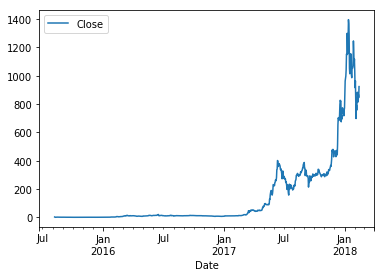

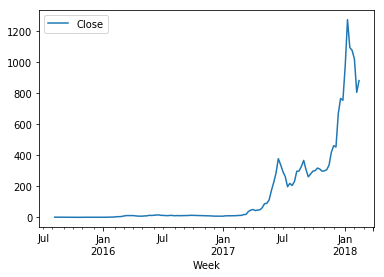

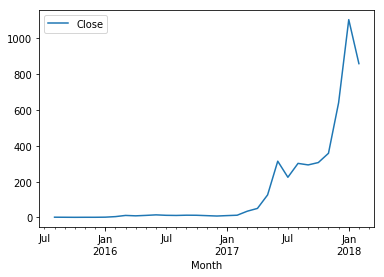

In [7]:
figure = plt.figure(figsize=(15, 5))

daily_df.plot(y='Close')
plt.show()

weekly_df.plot(y='Close')
plt.show()

monthly_df.plot(y='Close')
plt.show()

In [8]:
print len(daily_df)
print daily_df.head(15)
print daily_df.tail(15)

923
                Open      High       Low     Close   Volume   Market Cap
Date                                                                    
2015-08-07  2.830000  3.540000  2.520000  2.770000   164329          0.0
2015-08-08  2.790000  2.800000  0.714725  0.753325   674188  167911000.0
2015-08-09  0.706136  0.879810  0.629191  0.701897   532170   42637600.0
2015-08-10  0.713989  0.729854  0.636546  0.708448   405283   43130000.0
2015-08-11  0.708087  1.130000  0.663235  1.070000  1463100   42796500.0
2015-08-12  1.060000  1.290000  0.883608  1.220000  2150620   64018400.0
2015-08-13  1.220000  1.970000  1.170000  1.830000  4068680   73935400.0
2015-08-14  1.810000  2.260000  1.750000  1.830000  4637030  109594000.0
2015-08-15  1.800000  1.880000  1.570000  1.690000  2554360  109160000.0
2015-08-16  1.680000  1.700000  1.090000  1.570000  3550790  102028000.0
2015-08-17  1.580000  1.580000  1.190000  1.200000  1942830   95819700.0
2015-08-18  1.220000  1.330000  1.090000  1.090

In [9]:
# Market (Global) parameters


class MarketParameters:
    """
    Defines global market parameters for the entire application.
    """
    
    transaction_fee_perc = 0.01
    transaction_fee_flat = 0
    min_transaction_size_crypto = 0.1
    min_transaction_size_fiat = 1
    max_transaction_size_crypto = 100
    max_transaction_size_fiat = 100
    
    def __init__(self, transaction_fee_perc=None, transaction_fee_flat=None, 
                 min_transaction_size_crypto=None, min_transaction_size_fiat=None, 
                 max_transaction_size_crypto=None, max_transaction_size_fiat=None):
        
        if transaction_fee_perc and (transaction_fee_perc < 0 or transaction_fee_perc > 1):
            raise ValueError('Transaction fee (%) must be between 0 and 1')
        
        self.transaction_fee_perc = transaction_fee_perc or self.transaction_fee_perc
        self.transaction_fee_flat = transaction_fee_flat or self.transaction_fee_flat
        self.min_transaction_size_crypto = min_transaction_size_crypto or self.min_transaction_size_crypto
        self.min_transaction_size_fiat = min_transaction_size_fiat or self.min_transaction_size_fiat
        self.max_transaction_size_crypto = max_transaction_size_crypto or self.max_transaction_size_crypto
        self.max_transaction_size_fiat = max_transaction_size_fiat or self.max_transaction_size_fiat
        
    def __str__(self):
        string = "TXN fee (%): {0:.2f}\n".format(self.transaction_fee_perc)
        string += "TXN fee (flat): {0}\n".format(self.transaction_fee_flat)
        string += "Min TXN size (crypto): {0}\n".format(self.min_transaction_size_crypto)
        string += "Min TXN size (fiat): {0}\n".format(self.min_transaction_size_fiat)
        string += "Max TXN size (crypto): {0}\n".format(self.max_transaction_size_crypto)
        string += "Max TXN size (fiat): {0}".format(self.max_transaction_size_fiat)
        
        return string
        
        
market = MarketParameters()
print market

TXN fee (%): 0.01
TXN fee (flat): 0
Min TXN size (crypto): 0.1
Min TXN size (fiat): 1
Max TXN size (crypto): 100
Max TXN size (fiat): 100


In [10]:
from random import randint
from abc import ABCMeta, abstractmethod


class CryptoPredictor:
    """
    Abstract class CryptoPredictor.
    Predicts what cryptocurrency transaction to perform (buy/sell)
    given historical price data.
    The predictor can be run on a time period to estimate total ROI
    at the end based on the predicted transactions.
    """
    __metaclass__ = ABCMeta

    # Initial conditions
    total_investment = 0
    cash = 0
    transactions = []

    # Default parameters
    _starting_investment = 100.0  # USD
    _daily_allowance = 5.0
    _lookahead_days = 1

    def __init__(self, market, starting_date, price_list, opening_price_list, window_size, crypto_name,
                 starting_investment=None, daily_allowance=None, lookahead_days=None):

        self.market = market
        self._starting_date = starting_date
        self._price_list = price_list
        self._opening_price_list = opening_price_list
        self._window_size = window_size
        self._crypto_name = crypto_name

        # Override default parameters
        self._starting_investment = starting_investment or self._starting_investment
        self._daily_allowance = daily_allowance or self._daily_allowance
        self._lookahead_days = lookahead_days or self._lookahead_days

        # Dependent parameters
        self.total_investment += self._starting_investment
        self._starting_price = float(price_list[0])
        self.owned_crypto = self._starting_investment / self._starting_price

    @abstractmethod
    def get_transaction(self, prices, current_price, future_price):
        # type: (list, float, float) -> (str, float)
        """
        Child classes must override this method to define a way of doing a transaction based on the given
        parameters.
        :param prices: a list of the last self._window_size prices of the given cryptocurrency
        :param current_price: the price of the cryptocurrency at the present day
        :param future_price: the future price of the cryptocurrency
        :return: a tuple of the form (transaction, amount), where transaction can be 'BUY' or 'SELL'
        """
        pass

    def get_max_crypto_transaction(self, buy, current_price):
        """
        Get the maximum crypto transaction amount allowed based on transaction type, current cash,
        current price, and transaction fee.
        :param buy: True if buying, False if selling
        :param current_price: The current price (in fiat) of the cryptocurrency
        :return The max crypto amount (e.g. ETH) currently allowed on a transaction
        """
        if buy:
            crypto_amount = (self.cash / current_price) - (self.cash / current_price) * self.market.transaction_fee_perc
        else:
            crypto_amount = self.owned_crypto - self.owned_crypto * self.market.transaction_fee_perc

        return crypto_amount

    def get_transaction_fiat_amount(self, buy, crypto_amount, current_price):
        """
        Get the fiat amount of a transaction to perform.
        :param buy: True if buying, False if selling
        :param crypto_amount: The amount of crypto to buy/sell
        :param current_price: The current price (in fiat) of the cryptocurrency
        :return The fiat amount (e.g. USD) of a transaction.
        """
        if buy:
            return (crypto_amount * current_price) + (crypto_amount * current_price * self.market.transaction_fee_perc)
        else:
            return (crypto_amount * current_price) - (crypto_amount * current_price * self.market.transaction_fee_perc)

    def perform_transaction(self, buy, crypto_amount, current_price):
        """
        Perform a cryptocurrency transaction.
        :param buy: True if buying, False if selling
        :param crypto_amount: The amount of crypto to buy/sell
        :param current_price: The current price (in fiat) of the cryptocurrency
        """
        # Check for crypto transaction limits
        if crypto_amount > self.market.max_transaction_size_crypto:
            crypto_amount = self.market.max_transaction_size_crypto

        # Check that predictor is not cheating (buying/selling more than it can)
        max_crypto_amount = self.get_max_crypto_transaction(buy, current_price)
        if crypto_amount > max_crypto_amount:
            crypto_amount = max_crypto_amount

        if buy:
            fiat_amount = self.get_transaction_fiat_amount(True, crypto_amount, current_price)
            self.cash -= fiat_amount
            self.owned_crypto += crypto_amount
            assert self.cash >= 0
        else:
            fiat_amount = self.get_transaction_fiat_amount(False, crypto_amount, current_price)
            self.cash += fiat_amount
            self.owned_crypto -= crypto_amount
            assert self.owned_crypto >= 0

        logger.debug(
            "{0} - {1} {2} (${3})".format('BUY' if buy else 'SELL', self._crypto_name, crypto_amount, fiat_amount))

    def run_predictor(self):
        """
        Run the predictor, which will calculate cash and crypto amounts daily based on the
        transaction strategy.
        :return: a list of dictionaries with prices (training attributes) and transaction (class buy/sell)
        Example: [{[price1, price2, price3, ...], transaction: 'BUY'}, ...]
        """
        # Start trading
        logger.info("Running predictor for {0}...".format(self.__class__.__name__))
        logger.info("Starting date: {0}".format(self._starting_date))
        day = 1
        stop_day = 0
        current_price = 0
        for start_day in range(len(self._price_list) - self._window_size):
            stop_day = start_day + self._window_size
            logger.debug("Day {0} - {1}".format(day, self._price_list.index[stop_day]))
            time_window = self._price_list[start_day:stop_day]
            lookahead_day = stop_day + self._lookahead_days - 1
            future_price = self._price_list[lookahead_day]
            current_price = float(self._opening_price_list[stop_day])
            transaction = self.get_transaction(time_window, current_price, future_price)  # type: tuple

            if len(transaction) < 2:
                raise ValueError("get_transaction() method must return a tuple of the form (TRANSACTION_TYPE, "
                                 "CRYPTO_AMOUNT)")

            transaction_type = transaction[0]
            crypto_amount = transaction[1]

            self.perform_transaction(transaction_type == 'BUY', crypto_amount, current_price)

            # End of the day allowance
            self.cash += self._daily_allowance
            self.total_investment += self._daily_allowance

            # Build transaction dict
            transaction_dict = {
                'prices': time_window,
                'transaction': transaction_type
            }
            self.transactions.append(transaction_dict)

            day += 1

        logger.info("Finished running predictor")
        logger.info("End date: {0}".format(self._price_list.index[stop_day]))
        self._sell_all_crypto(current_price)  # Sell everything

        return self.transactions

    def _sell_all_crypto(self, current_price):
        """
        Sell all crypto in wallet given the last price.
        :param current_price: The current price (in fiat) of the crypto
        """
        self.cash += (self.owned_crypto * current_price) - (
                    self.owned_crypto * current_price * self.market.transaction_fee_perc)
        self.owned_crypto = 0

        logger.info("Cash: ${0}".format(self.cash))
        logger.info("Owned crypto: {0} {1}".format(self._crypto_name, self.owned_crypto))
        logger.info("Total investment: ${0}".format(self.total_investment))
        logger.info("ROI: ${0}".format(self.cash - self.total_investment))
        logger.info("*" * 20)


class BiffPredictor(CryptoPredictor):
    """
    Class BiffPredictor.
    Predicts what cryptocurrency transaction to perform (buy/sell)
    given historical price data and looking at the future price after a number of "lookahead" days.
    The strategy is to buy what you can with your cash if future price is higher than current price.
    Sell all if future price is lower than or equal to current price.
    """

    def get_transaction(self, prices, current_price, future_price):
        """
        Buy what you can with your cash if future price is higher than current price.
        Sell all if future price is lower than or equal to current price.
        """
        logger.debug("Cash: ${0}".format(self.cash))
        logger.debug("Owned crypto: {0} {1}".format(self._crypto_name, self.owned_crypto))
        logger.debug("Prices: {0}".format(prices))
        logger.debug("Current price: ${0}".format(current_price))
        logger.debug("Future price: ${0}".format(future_price))

        if future_price > current_price:  # Buy what you can with your cash
            transaction = 'BUY'
            crypto_amount = self.get_max_crypto_transaction(True, current_price)
            fiat_amount = (crypto_amount * current_price)
            fee = fiat_amount * self.market.transaction_fee_perc
            fiat_amount += fee
        else:  # Sell ALL
            transaction = 'SELL'
            crypto_amount = self.owned_crypto
            fiat_amount = (crypto_amount * current_price)
            fee = fiat_amount * self.market.transaction_fee_perc
            fiat_amount -= fee

        logger.debug("Transaction fee: ${0}".format(fee))
        logger.debug("Crypto amount: {0} {1}".format(self._crypto_name, crypto_amount))
        logger.debug("Fiat amount: ${0}".format(fiat_amount))

        # Ignore for transactions less than or close to a minimum crypto/fiat transaction
        if crypto_amount < self.market.min_transaction_size_crypto or \
                round(fiat_amount, 0) < self.market.min_transaction_size_fiat:
            crypto_amount = 0

        return transaction, crypto_amount


class ReverseBiffPredictor(CryptoPredictor):
    """
    Class ReverseBiffPredictor.
    Predicts what cryptocurrency transaction to perform (buy/sell)
    given historical price data and looking at the future price after a number of "lookahead" days.
    The strategy is to buy what you can with your cash if future price is lower than or equal current price.
    Sell all if future price is higher than current price.
    """

    def get_transaction(self, prices, current_price, future_price):
        """
        Buy what you can with your cash if future price is lower than or equal to current price.
        Sell all if future price is higher than current price.
        """
        if future_price <= current_price:  # Buy what you can with your cash
            transaction = 'BUY'
            crypto_amount = (self.cash / current_price) - (self.cash / current_price) * self.market.transaction_fee_perc
            fiat_amount = (crypto_amount * current_price)
            fee = fiat_amount * self.market.transaction_fee_perc
            fiat_amount += fee
        else:  # Sell ALL
            transaction = 'SELL'
            crypto_amount = self.owned_crypto
            fiat_amount = (crypto_amount * current_price)
            fee = fiat_amount * self.market.transaction_fee_perc
            fiat_amount -= fee

        # Ignore for transactions less than or close to a minimum crypto/fiat transaction
        if crypto_amount < self.market.min_transaction_size_crypto or \
                round(fiat_amount, 0) < self.market.min_transaction_size_fiat:
            crypto_amount = 0

        return transaction, crypto_amount


class LazyPredictor(CryptoPredictor):
    """
    Class LazyPredictor.
    Don't do anything. Just wait to see if you get rich by lying on your sofa.
    """

    def get_transaction(self, prices, current_price, future_price):
        """
        I'm a lazy fuck, I don't do anything...ever.
        """
        transaction = 'BUY'
        crypto_amount = 0
        return transaction, crypto_amount


class RandomPredictor(CryptoPredictor):
    """
    Class RandomPredictor.
    Just be random AF when making transactions.
    """

    def get_transaction(self, prices, current_price, future_price):
        """
        Buy what you can with your cash or sell all, randomly.
        """
        transaction_no = randint(0, 1)
        if transaction_no == 0:
            transaction = 'BUY'
            crypto_amount = (self.cash / current_price) - (self.cash / current_price) * self.market.transaction_fee_perc
            fiat_amount = (crypto_amount * current_price)
            fee = fiat_amount * self.market.transaction_fee_perc
            fiat_amount += fee
        else:
            transaction = 'SELL'
            crypto_amount = self.owned_crypto
            fiat_amount = (crypto_amount * current_price)
            fee = fiat_amount * self.market.transaction_fee_perc
            fiat_amount -= fee

        logger.debug("Transaction fee: ${0}".format(fee))

        # Ignore for transactions less than or close to a minimum crypto/fiat transaction
        if crypto_amount < self.market.min_transaction_size_crypto or \
                round(fiat_amount, 0) < self.market.min_transaction_size_fiat:
            crypto_amount = 0

        return transaction, crypto_amount


class GreedyPredictor(CryptoPredictor):
    """
    Class GreedyPredictor.
    Always buy with whatever cash is available. NEVER sell.
    """

    def get_transaction(self, prices, current_price, future_price):
        """
        Buy what you can with your cash all the time.
        """
        transaction = 'BUY'
        crypto_amount = (self.cash / current_price) - (self.cash / current_price) * self.market.transaction_fee_perc
        fiat_amount = (crypto_amount * current_price)
        fee = fiat_amount * self.market.transaction_fee_perc
        fiat_amount += fee

        logger.debug("Transaction fee: ${0}".format(fee))

        # Ignore for transactions less than or close to a minimum crypto/fiat transaction
        if crypto_amount < self.market.min_transaction_size_crypto or \
                round(fiat_amount, 0) < self.market.min_transaction_size_fiat:
            crypto_amount = 0

        return transaction, crypto_amount


class ProbabilityPredictor(CryptoPredictor):
    """
    Class ProbabilityPredictor.
    Predict 'BUY' or 'SELL' based on a probability for each transaction type.
    For instance, if prob_buy = 0.4, then prob_sell = 1 - prob_buy = 0.6.
    """

    def __init__(self, market, starting_date, price_list, opening_price_list, window_size, crypto_name,
                 starting_investment=None, daily_allowance=None, lookahead_days=None, prob_buy=1, prob_sell=1):
        """
        ProbabilityPredictor constructor. The parameters are the same as those in CryptoPredictor with the exception of
        prob_buy and prob_sell, which indicate the random probability [0-1] that the transaction will be 'BUY' when it
        needs to buy and 'SELL' when it needs to sell. The rules for buying or selling are the same as the
        BiffPredictor.
        :param market:
        :param starting_date:
        :param price_list:
        :param opening_price_list:
        :param window_size:
        :param crypto_name:
        :param starting_investment:
        :param daily_allowance:
        :param lookahead_days:
        :param prob_buy: A value between 0 and 1 which indicates the probability that the transaction will be 'BUY'
        when it actually has to buy, based on BiffPredictor rules.
        :param prob_sell: A value between 0 and 1 which indicates the probability that the transaction will be 'SELL'
        when it actually has to sell, based on BiffPredictor rules.
        """
        super(ProbabilityPredictor, self).__init__(market, starting_date, price_list, opening_price_list, window_size,
                                                   crypto_name, starting_investment, daily_allowance, lookahead_days)

        if prob_buy < 0 or prob_buy > 1:
            raise ValueError("prob_buy should be a decimal between 0 (inclusive) and 1 (inclusive).")

        if prob_sell < 0 or prob_sell > 1:
            raise ValueError("prob_sell should be a decimal between 0 (inclusive) and 1 (inclusive).")

        self._prob_buy = prob_buy
        self._prob_sell = prob_sell

    def get_transaction(self, prices, current_price, future_price):
        """
        Get a transaction based on luck (accuracies for BUY and SELL) given prob_buy and prob_sell and BiffPredictor's
        strategy:
        Buy what you can with your cash if future price is higher than current price.
        Sell all if future price is lower than or equal to current price.
        """

        random_draw = randint(0, 100)
        if future_price > current_price:  # Buy what you can with your cash
            keep = random_draw <= int(self._prob_buy * 100)
            if keep:
                transaction = 'BUY'
                crypto_amount = self.get_max_crypto_transaction(True, current_price)
                fiat_amount = (crypto_amount * current_price)
                fee = fiat_amount * self.market.transaction_fee_perc
                fiat_amount += fee
            else:
                transaction = 'SELL'
                crypto_amount = self.owned_crypto
                fiat_amount = (crypto_amount * current_price)
                fee = fiat_amount * self.market.transaction_fee_perc
                fiat_amount -= fee
        else:  # Sell ALL
            keep = random_draw <= int(self._prob_sell * 100)
            if keep:
                transaction = 'SELL'
                crypto_amount = self.owned_crypto
                fiat_amount = (crypto_amount * current_price)
                fee = fiat_amount * self.market.transaction_fee_perc
                fiat_amount -= fee
            else:
                transaction = 'BUY'
                crypto_amount = self.get_max_crypto_transaction(True, current_price)
                fiat_amount = (crypto_amount * current_price)
                fee = fiat_amount * self.market.transaction_fee_perc
                fiat_amount += fee

        # Ignore for transactions less than or close to a minimum crypto/fiat transaction
        if crypto_amount < self.market.min_transaction_size_crypto or \
                round(fiat_amount, 0) < self.market.min_transaction_size_fiat:
            crypto_amount = 0

        return transaction, crypto_amount


In [26]:
# Run predictors

# Required predictor parameters
starting_date = date(2017, 1, 1)  # 2015 8 7
column = 'Close'
price_list = daily_df[column][starting_date:]
opening_price_list = daily_df['Open'][starting_date:]
window_size = 30
crypto_name = 'ETH'

biff = BiffPredictor(market, starting_date, price_list, opening_price_list, window_size, crypto_name)
biff.run_predictor()
'''
reverse_biff = ReverseBiffPredictor(starting_date, price_list, opening_price_list, starting_investment, daily_allowance)
reverse_biff.run_predictor()

lazy_fuck = LazyPredictor(starting_date, price_list, opening_price_list, starting_investment, daily_allowance)
lazy_fuck.run_predictor()

random_guy = RandomPredictor(starting_date, price_list, opening_price_list, starting_investment, daily_allowance)
random_guy.run_predictor()

greedy = GreedyPredictor(starting_date, price_list, opening_price_list, starting_investment, daily_allowance)
greedy.run_predictor()
'''
print 'Transactions: {0}'.format(len(biff.transactions))
print biff.transactions[-1:]

INFO:root:Running predictor for BiffPredictor...
INFO:root:Starting date: 2017-01-01
INFO:root:Finished running predictor
INFO:root:End date: 2018-02-14 00:00:00
INFO:root:Cash: $604255.628259
INFO:root:Owned crypto: ETH 0
INFO:root:Total investment: $2000.0
INFO:root:ROI: $602255.628259
INFO:root:********************


Transactions: 380
[{'prices': Date
2018-01-15    1291.92
2018-01-16    1053.69
2018-01-17    1014.25
2018-01-18    1036.28
2018-01-19    1039.10
2018-01-20    1155.15
2018-01-21    1049.58
2018-01-22    1003.26
2018-01-23     986.23
2018-01-24    1058.78
2018-01-25    1056.03
2018-01-26    1055.17
2018-01-27    1107.07
2018-01-28    1246.01
2018-01-29    1182.36
2018-01-30    1071.13
2018-01-31    1118.31
2018-02-01    1036.79
2018-02-02     915.79
2018-02-03     964.02
2018-02-04     834.68
2018-02-05     697.95
2018-02-06     793.12
2018-02-07     757.07
2018-02-08     817.81
2018-02-09     883.87
2018-02-10     860.42
2018-02-11     814.66
2018-02-12     868.71
2018-02-13     845.26
Name: Close, dtype: float64, 'transaction': 'BUY'}]


In [27]:
# Prepare classification dataset from transactions


def build_transactions_df(transactions):
    """
    Build a DataFrame ready for classification (i.e., X and y) based on a dictionary of transactions.
    :param transactions: A list of dictionaries of the form 
    [{'transaction': 'TRANSACTION_TYPE', 'prices': [price1, price2, ...]}, ...]
    :return: A DataFrame with N price columns and a transaction column (1=BUY, 0=SELL)
    """
    prices = list(transactions[0]['prices'])

    # Price columns
    df_columns = ["price {0}".format(column_name) for column_name in range(1, len(prices) + 1)]
    df_columns.append('transaction')

    df = DataFrame(columns=df_columns)
    for row in range(len(transactions)):
        prices = list(transactions[row]['prices'])
        transaction = 1 if transactions[row]['transaction'] == 'BUY' else 0
        df.loc[row] = prices + [transaction]
    
    df['transaction'] = df['transaction'].astype(int)
    
    return df


transactions_df = build_transactions_df(biff.transactions)

print 'Buy: {0}'.format(len(transactions_df[transactions_df['transaction'] == 1]))
print 'Sell: {0}'.format(len(transactions_df[transactions_df['transaction'] == 0]))
transactions_df.head()

Buy: 203
Sell: 177


,price 1,price 2,price 3,price 4,price 5,price 6,price 7,price 8,price 9,price 10,...,price 22,price 23,price 24,price 25,price 26,price 27,price 28,price 29,price 30,transaction
0,8.17,8.38,9.73,11.25,10.25,10.25,9.87,10.29,10.33,10.55,...,10.70,10.82,10.63,10.57,10.59,10.54,10.56,10.48,10.57,1
1,8.38,9.73,11.25,10.25,10.25,9.87,10.29,10.33,10.55,9.72,...,10.82,10.63,10.57,10.59,10.54,10.56,10.48,10.57,10.73,0
2,9.73,11.25,10.25,10.25,9.87,10.29,10.33,10.55,9.72,9.86,...,10.63,10.57,10.59,10.54,10.56,10.48,10.57,10.73,10.73,1
3,11.25,10.25,10.25,9.87,10.29,10.33,10.55,9.72,9.86,9.77,...,10.57,10.59,10.54,10.56,10.48,10.57,10.73,10.73,10.82,1
4,10.25,10.25,9.87,10.29,10.33,10.55,9.72,9.86,9.77,9.65,...,10.59,10.54,10.56,10.48,10.57,10.73,10.73,10.82,11.11,1


In [28]:
# Prepare data for classification (Normalization by row)

from sklearn.preprocessing import StandardScaler


def normalize_df_by_row(df, by_row):
    """
    Normalize a DataFrame either by row using feature scaling, or using scikit-learn's
    StandardScaler (by column).
    A value is normalized in the row using the feature scaling formula to be in the range [0, 1]:
    x' = (x - x_min) / (x_max - x_min)
    :param df: The DataFrame to normalize
    :param by_row: If True, normalizes by row using feature scaling, if False, uses
    scikit-learn's FeatureScaler, which scales by column and using variance.
    :return: A new DataFrame with each row normalized
    """
    if by_row:
        norm_df = df.copy(deep=True)
        for row in range(len(df)):
            norm_df.iloc[row, :-1] = (df.iloc[row, :-1] - df.iloc[row, :-1].min()) / \
                                           (df.iloc[row, :-1].max() - df.iloc[row, :-1].min())
    else:
        scaler = StandardScaler()
        scaler.fit(df.iloc[:, :-1])
        norm_df = DataFrame(scaler.transform(df.iloc[:, :-1]))
        norm_df['transaction'] = df['transaction']
        
    return norm_df


normalized_df = normalize_df_by_row(transactions_df, False)
print normalized_df.head()

          0         1         2         3         4         5         6  \
0 -0.979920 -0.978857 -0.974428 -0.969211 -0.973635 -0.972257 -0.974538   
1 -0.979102 -0.973657 -0.968630 -0.972988 -0.973635 -0.973660 -0.973001   
2 -0.973844 -0.967802 -0.972444 -0.972988 -0.975056 -0.972109 -0.972855   
3 -0.967924 -0.971654 -0.972444 -0.974423 -0.973485 -0.971962 -0.972050   
4 -0.971819 -0.971654 -0.973894 -0.972837 -0.973335 -0.971149 -0.975086   

          7         8         9     ...             21        22        23  \
0 -0.974789 -0.976787 -0.977168     ...      -1.002032 -1.006506 -1.012181   
1 -0.974644 -0.975995 -0.980132     ...      -1.001638 -1.007128 -1.012377   
2 -0.973846 -0.978985 -0.979632     ...      -1.002261 -1.007325 -1.012311   
3 -0.976858 -0.978480 -0.979953     ...      -1.002458 -1.007259 -1.012475   
4 -0.976350 -0.978805 -0.980381     ...      -1.002393 -1.007423 -1.012409   

         24        25        26        27        28        29  transaction  
0 -

In [38]:
# Prepare datasets for classification

from sklearn.model_selection import train_test_split


def get_datasets(df, shuffle, training_size, dev_size):
    """
    Get split datasets from a DataFrame used for non-CV (no Cross Validation), CV, and Grid Search CV.
    For non-CV, the DF is split into X_training, y_training, X_testing, y_testing.
    For CV, the given DF is simply split into X (attributes) and y (target/classes).
    For Grid Search CV, the DF is split into X_dev, y_dev, X_eval, y_eval. In Grid Search CV,
    the X and y must be split into development and evaluation subsets, as the development data
    is used for finding the best hyperparameter values, and the evaluation data is used
    to test a model with those values (and avoid overfitting).
    :param df: The DataFrame to split
    :param shuffle: Whether or not to shuffle the rows of the DF (TODO: use in time series?)
    :param training_size: The size of the training dataset (0~1)
    :param dev_size: The size of the development dataset (0~1)
    :return: 
    """
    if shuffle:
        shuffled_df = df.sample(frac=1)

        # Used for non-CV
        training_data = shuffled_df.sample(frac=training_size)
        testing_data = shuffled_df[~shuffled_df.index.isin(training_data.index)]
        
        # Used for CV
        X = shuffled_df.iloc[:, :-1]
        y = shuffled_df['transaction']
        
        # Used for Grid Search CV
        X_dev, X_eval, y_dev, y_eval = train_test_split(X, y, test_size=dev_size)
    else:
        # Used for non-CV
        training_data = df[:int(len(df)*training_size)]
        testing_data = df[~df.index.isin(training_data.index)]
        
        # Used for CV
        X = df.iloc[:, :-1]
        y = df['transaction']
        
        # Used for Grid Search CV
        dev_set = df[:int(len(df)*dev_size)]
        eval_set = df[~df.index.isin(dev_set.index)]
        X_dev = dev_set.iloc[:, :-1]
        y_dev = dev_set.iloc[:, -1:]
        X_eval = eval_set.iloc[:, :-1]
        y_eval = eval_set.iloc[:, -1:]
    
    # Used for non-CV
    X_training = training_data.iloc[:, :-1]
    y_training = training_data.iloc[:, -1:]
    X_testing = testing_data.iloc[:, :-1]
    y_testing = testing_data.iloc[:, -1:]
    
    return X, y, X_training, y_training, X_testing, y_testing, X_dev, y_dev, X_eval, y_eval


# Data set parameters
normalize = True
shuff = True
training_sz = 0.7  # Used for non-CV
dev_sz = 0.5  # Used for Grid Search CV

if normalize:
    final_df = normalized_df
else:
    final_df = transactions_df
    
X, y, X_training, y_training, X_testing, y_testing, X_dev, y_dev, X_eval, y_eval = \
    get_datasets(final_df, shuff, training_sz, dev_sz)

print "Length X: {0}".format(len(X))
print "Length X_training: {0}".format(len(X_training))
print "Length X_testing: {0}".format(len(X_testing))
print "Length X_dev: {0}".format(len(X_dev))
print "Length X_eval: {0}".format(len(X_eval))

print X.tail()

Length X: 380
Length X_training: 266
Length X_testing: 114
Length X_dev: 190
Length X_eval: 190
           0         1         2         3         4         5         6   \
22  -0.969598 -0.970191 -0.971224 -0.971703 -0.972550 -0.971112 -0.972306   
340  0.680229  0.745374  0.794781  0.656651  0.914748  1.395083  1.559782   
354  2.186181  1.588249  1.732812  1.610065  1.852375  1.847040  1.779491   
348  1.654102  1.670484  1.735063  1.989610  2.080489  2.014110  1.992434   
187 -0.053642 -0.041652 -0.087821 -0.198298 -0.273659 -0.158062 -0.243539   

           7         8         9     ...           20        21        22  \
22  -0.973773 -0.975347 -0.976526    ...    -0.994563 -1.000163 -0.999273   
340  1.512736  1.451496  1.470727    ...     1.471476  1.379759  1.424678   
354  1.662235  1.700549  1.545878    ...     3.089314  2.750194  3.125430   
348  1.436681  1.577356  1.463372    ...     2.187161  2.234662  2.367634   
187 -0.287638 -0.399254 -0.453038    ...    -0.361448 -0

In [39]:
from sklearn import svm, dummy
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report

# Classifiers
svm_linear = svm.SVC(kernel='linear')
svm_rbf = svm.SVC(kernel='rbf')
svm_poly = svm.SVC(kernel='poly')
mlp_nn = MLPClassifier()
dummy_clf = dummy.DummyClassifier()

In [40]:
scores = cross_val_score(svm_linear, X, y, cv=4, scoring='accuracy')
print "Linear SVM accuracy: {0:.2f}±{1:.2f}".format(scores.mean(), scores.std())

Linear SVM accuracy: 0.54±0.01


In [41]:
scores = cross_val_score(svm_rbf, X, y, cv=4, scoring='accuracy')
print "RBF SVM accuracy: {0:.2f}±{1:.2f}".format(scores.mean(), scores.std())

RBF SVM accuracy: 0.54±0.03


In [42]:
scores = cross_val_score(svm_poly, X, y, cv=4, scoring='accuracy')
print "Poly SVM accuracy: {0:.2f}±{1:.2f}".format(scores.mean(), scores.std())

Poly SVM accuracy: 0.55±0.02


In [43]:
scores = cross_val_score(mlp_nn, X, y, cv=4, scoring='accuracy')
print "MLP NN accuracy: {0:.2f}±{1:.2f}".format(scores.mean(), scores.std())

MLP NN accuracy: 0.57±0.04


In [44]:
scores = cross_val_score(dummy_clf, X, y, cv=4, scoring='accuracy')
print "Dummy accuracy: {0:.2f}±{1:.2f}".format(scores.mean(), scores.std())

Dummy accuracy: 0.51±0.06


In [45]:
# Grid Search CV (development and evaluation datasets) function


def get_optimized_classifier(classifier, tuned_parameters, X_dev, y_dev, X_eval, y_eval, k=4):
    """
    Perform a Grid Search algorithm with Cross Validation to find the optimal hyperparameter
    values and test the optimized model.
    :param classifier: The classifier to use
    :param tuned_parameters: A dictionary of parameter combinations to test
    :param X_dev: The development dataset attributes
    :param y_dev: The development dataset targets (labels)
    :param X_eval: The evaluation dataset attributes
    :param y_eval: The evaluation dataset targets (labels)
    :param k: (default: 4) The number of folds used in cross validation
    :return: The trained Grid Search classifier with optimized hyperparameters
    :rtype: GridSearchCV
    """
    logger.info("Tuning hyperparameters for {0} for accuracy...".format(classifier.__class__.__name__))
    
    clf = GridSearchCV(classifier, tuned_parameters, cv=k, scoring='accuracy')
    clf.fit(X_dev, y_dev)
    
    logger.info("Best parameters set found on development dataset:\n")
    logger.info(clf.best_params_)
    
    logger.debug("\nGrid scores on development set:\n")
    means = clf.cv_results_['mean_test_score']
    stds = clf.cv_results_['std_test_score']
    parameters = clf.cv_results_['params']
    for mean, std, params in zip(means, stds, parameters):
        logger.debug("%0.3f (+/-%0.03f) for %r" % (mean, std * 2, params))
    print '\n'
    
    # Evaluation dataset
    
    logger.info("\nDetailed classification report:\n")
    logger.info("The model is trained on the full development set (size {0}).".format(len(X_dev)))
    logger.info("The scores are computed on the full evaluation set (size {0}).\n".format(len(X_eval)))
    y_true, y_pred = y_eval, clf.predict(X_eval)
    logger.info('\n' + classification_report(y_true, y_pred))
    
    return clf

In [46]:
# Grid Search CV with SVMs

svc = svm.SVC()
svm_tuned_parameters = [{'kernel': ["rbf", "poly"], 'gamma': [1e-3, 1e-4], 'C': [0.01, 0.1, 1, 10, 100, 1000]},
                        {'kernel': ["linear"], 'C': [0.01, 0.1, 1, 10, 100, 1000]}]
grid_search_cv_svc = get_optimized_classifier(svc, svm_tuned_parameters, X_dev, y_dev, X_eval, y_eval)

INFO:root:Tuning hyperparameters for SVC for accuracy...
INFO:root:Best parameters set found on development dataset:

INFO:root:{'kernel': 'linear', 'C': 1000}
INFO:root:
Detailed classification report:

INFO:root:The model is trained on the full development set (size 190).
INFO:root:The scores are computed on the full evaluation set (size 190).

INFO:root:
             precision    recall  f1-score   support

          0       0.54      0.45      0.49        87
          1       0.59      0.68      0.63       103

avg / total       0.57      0.57      0.57       190



In [47]:
# Get the best estimator instance and refit

clf_svc = grid_search_cv_svc.best_estimator_
clf_svc.fit(X, y)

y_true, y_pred = y, clf_svc.predict(X)
logger.info('\n' + classification_report(y_true, y_pred))

INFO:root:
             precision    recall  f1-score   support

          0       0.71      0.46      0.56       177
          1       0.64      0.83      0.72       203

avg / total       0.67      0.66      0.65       380



In [48]:
# Grid Search CV with NNs

mlp = MLPClassifier()
mlp_tuned_parameters = {
    'learning_rate': ["constant", "invscaling", "adaptive"],
    'hidden_layer_sizes': [(10, 10, 10), (20, 20, 20), (30, 30, 30)],
    'alpha': [0.1, 1, 10, 100],
    'activation': ["identity", "logistic", "tanh", "relu"]
}

grid_search_cv_nn = get_optimized_classifier(mlp, mlp_tuned_parameters, X_dev, y_dev, X_eval, y_eval)


INFO:root:Tuning hyperparameters for MLPClassifier for accuracy...
D:\Dropbox\Personal\Finanzas\Cryptocurrencies\Code\CryptonalysisServer\venv\lib\site-packages\sklearn\neural_network\multilayer_perceptron.py:564: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
INFO:root:Best parameters set found on development dataset:

INFO:root:{'alpha': 10, 'activation': 'relu', 'learning_rate': 'constant', 'hidden_layer_sizes': (20, 20, 20)}
INFO:root:
Detailed classification report:

INFO:root:The model is trained on the full development set (size 190).
INFO:root:The scores are computed on the full evaluation set (size 190).

INFO:root:
             precision    recall  f1-score   support

          0       0.50      0.03      0.06        87
          1       0.54      0.97      0.70       103

avg / total       0.52      0.54      0.41       190



In [49]:
# API Data
class Endpoint:
    def __init__(self, url, parameters):
        self.url = url
        self.parameters = parameters
        
    def parameter_url(self):
        if len(self.parameters) == 0:
            return self.url
        else:
            return self.url + '?' + urllib.urlencode(self.parameters)


api_headers = {'Content-Type': 'application/json', 'Accept-Charset': 'UTF-8'}
    'global_data': Endpoint('https://api.coinmarketcap.com/v1/global', {}),
    'ticker': Endpoint('https://api.coinmarketcap.com/v1/ticker/ethereum', {})
}

# Global data
print 'Fetching data from ' + api_endpoints['global_data'].parameter_url() + ' ...'
r = requests.get(api_endpoints['global_data'].parameter_url(), headers=api_headers)
response = r.json()
logger.debug("\nGlobal data (raw):")
logger.debug(r.json())

global_df = pd.DataFrame.from_dict(response, orient='index')
global_df = global_df.transpose()
logger.info("\nGlobal data:")
logger.info(global_df)

# Ticker
print 'Fetching data from ' + api_endpoints['ticker'].parameter_url() + ' ...'
r = requests.get(api_endpoints['ticker'].parameter_url(), headers=api_headers)
response = r.json()
logger.debug("\nTicker data (raw):")
logger.debug(r.json())

ticker_df = pd.DataFrame.from_dict(response[0], orient='index')
ticker_df = ticker_df.transpose()
logger.info("\nTicker data:")
logger.info(ticker_df)

Fetching data from https://api.coinmarketcap.com/v1/global ...


INFO:root:
Global data:
INFO:root:   bitcoin_percentage_of_market_cap  last_updated  total_market_cap_usd  \
0                             36.34  1.518909e+09          5.123091e+11   

   active_markets  active_assets  active_currencies  total_24h_volume_usd  
0          8935.0          611.0              902.0          2.197203e+10  


Fetching data from https://api.coinmarketcap.com/v1/ticker/ethereum ...


INFO:root:
Ticker data:
INFO:root:  market_cap_usd price_usd last_updated      name 24h_volume_usd  \
0  95196350294.0   974.579   1518908951  Ethereum   2495820000.0   

  percent_change_7d symbol max_supply rank percent_change_1h total_supply  \
0             16.23    ETH       None    2              0.55   97679460.0   

   price_btc available_supply percent_change_24h        id  
0  0.0887983       97679460.0               3.21  ethereum  
